# LSTM — NinaPro DB7



## Cell 1 — Imports

In [1]:
import os, gc, time, json, warnings, random, re
from pathlib import Path
import numpy as np
import pandas as pd

from scipy import io
from scipy.signal import (
    resample_poly, butter, sosfiltfilt, iirnotch, filtfilt
)
from scipy.stats import skew, kurtosis
from math import gcd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('Imports done.')


Imports done.


## Cell 2 — Configuration

In [2]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir()
        )

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    result = _search(child, depth + 1)
                    if result is not None:
                        return result
        except PermissionError:
            pass
        return None

    result = _search(base)
    return result if result else Path('/kaggle/input/ninapro-db7/Dataset')


class Config:
    # Paths
    KAGGLE_INPUT   = _find_kaggle_input()
    KAGGLE_WORKING = (
        Path('/kaggle/working')
        if Path('/kaggle').exists()
        else Path.cwd() / 'lstm_within_emg_acc_working'
    )
    RUN_TAG = 'v14_lstm_subject_specific_emg_acc_leakage_safe'
    CKPT_DIR = KAGGLE_WORKING / f'ckpts_{RUN_TAG}'
    # Same continuous-signal cache convention as the improved GNN/LOSO pipeline.
    DATA_CACHE_DIR = KAGGLE_WORKING / f'raw_file_cache_{RUN_TAG}'
    FEATURE_CACHE_DIR = KAGGLE_WORKING / f'feature_cache_{RUN_TAG}'
    PLOT_DIR = KAGGLE_WORKING / f'plots_{RUN_TAG}'
    RESULTS_DIR = KAGGLE_WORKING / f'results_{RUN_TAG}'

    # Population
    INTACT_SUBJECTS  = list(range(1, 21))
    AMPUTEE_SUBJECTS = [21, 22]
    SUBJECTS = list(range(1, 23))
    # Run all subjects by default. For a quick Kaggle smoke test, use e.g. [1, 2].
    RUN_SUBJECTS = SUBJECTS.copy()
    PLOT_EACH_SUBJECT = False

    # Within-subject repetition protocol: DB7 has six repetitions/gesture.
    REPS_PER_GESTURE = 6
    TRAIN_REPS = 4
    VAL_REPS = 1
    TEST_REPS = 1

    # Labels 13..29 span E1 and E2.
    EXERCISE_NAME = 'labels13_29'
    EXERCISE_IDS = (1, 2)
    GESTURE_MIN = 13
    GESTURE_MAX = 29
    N_CLASSES = GESTURE_MAX - GESTURE_MIN + 1

    # Dataset
    EMG_FS = 2000
    ACC_FS = 148
    TARGET_FS = 2000
    EMG_KEY = 'emg'
    ACC_KEY = 'acc'
    LBL_KEY = 'restimulus'
    N_EMG_CH = 12

    # Strict multimodal experiment: temporal EMG LSTM + separate ACC branch.
    USE_ACC = True

    # Signal preprocessing
    BANDPASS_LOW_HZ  = 20.0
    BANDPASS_HIGH_HZ = 450.0
    FILTER_ORDER = 4
    NOTCH_HZ = 50.0
    NOTCH_Q = 30.0

    # Windowing retained from the GNN pipeline.
    WIN_MS = 400
    STEP_MS = 100
    TRIM_MS = 100
    WIN_SAMPLES = int(WIN_MS * TARGET_FS / 1000)
    STEP_SAMPLES = int(STEP_MS * TARGET_FS / 1000)
    TRIM_SAMPLES = int(TRIM_MS * TARGET_FS / 1000)

    # Subject-specific within-subject baseline: retain amplitude information.
    # RobustScaler is fitted separately for every subject on training repetitions only.
    NORMALIZE_EMG_WINDOW = False
    EMG_NORM_CLIP = 12.0

    # EMG features
    MAVSLP_SEGMENTS = 3
    AR_ORDER = 4
    USE_FREQ_FEATURES = False
    THRESHOLD_STD_FACTOR = 0.01
    WAMP_STD_FACTOR = 0.05
    FEATURE_CHUNK_SIZE = 2048

    # ACC-specific features, only if USE_ACC=True.
    ACC_FEATURE_NAMES = (
        'mean', 'std', 'rms', 'range',
        'mean_abs_diff', 'skew', 'kurtosis'
    )

    # Disabled by default for within-subject learning: electrode placement is stable
    # within the same subject, so LOSO-style shift/gain augmentation can be harmful.
    AUGMENT_TRAIN = False
    N_AUG_COPIES = 1
    AUGMENT_GAIN_STD = 0.15
    AUGMENT_NOISE_STD = 0.02
    AUGMENT_MAX_SHIFT = 1

    # LSTM temporal representation
    # One 400 ms outer window -> 4 consecutive 100 ms feature frames.
    LSTM_FRAME_MS = 100
    LSTM_STEPS = WIN_MS // LSTM_FRAME_MS
    LSTM_FRAME_SAMPLES = int(LSTM_FRAME_MS * TARGET_FS / 1000)
    LSTM_HIDDEN = 128
    LSTM_LAYERS = 2
    LSTM_BIDIRECTIONAL = False
    SEQ_EMBED_DIM = 128
    ACC_HIDDEN = [64, 32]
    FUSION_HIDDEN = 128
    DROPOUT = 0.15

    # Subject-adversarial training is useful mainly for unseen-subject LOSO.
    # It is disabled by default here because train/test contain the same subjects.
    # The code remains available for an ablation.
    USE_DOMAIN_ADVERSARIAL = False
    DOMAIN_ADV_LAMBDA = 0.10
    DOMAIN_LOSS_WEIGHT = 0.05
    N_DOMAINS = 22

    # Optimization
    MIN_EPOCHS = 20
    MAX_EPOCHS = 150
    PATIENCE = 15
    MIN_REFIT_EPOCHS = 10
    BATCH_SIZE = 128
    LR = 3e-4
    DECAY = 1e-4
    LABEL_SMOOTHING = 0.0
    GRAD_CLIP = 5.0
    NUM_WORKERS = 2

    # Valid within-subject final refit: use train+validation repetitions only.
    REFIT_ON_TRAIN_PLUS_VAL = True

    # Continuous cache version matches the improved 400 ms preprocessing.
    CACHE_VERSION = 'v14_raw_per_file_rep_local_emg_acc'
    WITHIN_FEATURE_CACHE_VERSION = 'v14_lstm_seq4_emg_acc_rep_local'

    # Reproducibility
    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for directory in [
    Config.CKPT_DIR, Config.DATA_CACHE_DIR, Config.FEATURE_CACHE_DIR,
    Config.PLOT_DIR, Config.RESULTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

assert Config.TRAIN_REPS + Config.VAL_REPS + Config.TEST_REPS == Config.REPS_PER_GESTURE

print(f'Device             : {Config.DEVICE}')
print(f'Population         : all DB7 subjects {Config.SUBJECTS}')
print(f'Subject models     : {Config.RUN_SUBJECTS}')
print('Exercise files      : E1 + E2')
print(f'Input modality     : {"temporal EMG + separate ACC branch" if Config.USE_ACC else "EMG only"}')
print('Leakage control    : split repetitions before EMG filtering / ACC resampling')
print(f'Window / step      : {Config.WIN_MS} / {Config.STEP_MS} ms')
print(f'Boundary trim      : {Config.TRIM_MS} ms per side')
print(f'Gestures           : {Config.GESTURE_MIN}–{Config.GESTURE_MAX} ({Config.N_CLASSES} classes)')
print(f'Within split       : {Config.TRAIN_REPS} train + {Config.VAL_REPS} val + {Config.TEST_REPS} test repetitions')
print(f'EMG normalization  : {Config.NORMALIZE_EMG_WINDOW}')
print(f'Train augmentation : {Config.AUGMENT_TRAIN} ({Config.N_AUG_COPIES} copy/copies)')
print(f'LSTM sequence      : {Config.LSTM_STEPS} × {Config.LSTM_FRAME_MS} ms frames')
print(f'LSTM hidden/layers : {Config.LSTM_HIDDEN} / {Config.LSTM_LAYERS}')
print(f'Domain adversarial : {Config.USE_DOMAIN_ADVERSARIAL}')
print(f'Refit train+val    : {Config.REFIT_ON_TRAIN_PLUS_VAL}')
assert Config.WIN_MS % Config.LSTM_FRAME_MS == 0
assert Config.LSTM_STEPS * Config.LSTM_FRAME_SAMPLES == Config.WIN_SAMPLES

assert Config.USE_ACC is True


Device             : cpu
Population         : all DB7 subjects [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Subject models     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Exercise files      : E1 + E2
Input modality     : temporal EMG + separate ACC branch
Leakage control    : split repetitions before EMG filtering / ACC resampling
Window / step      : 400 / 100 ms
Boundary trim      : 100 ms per side
Gestures           : 13–29 (17 classes)
Within split       : 4 train + 1 val + 1 test repetitions
EMG normalization  : False
Train augmentation : False (1 copy/copies)
LSTM sequence      : 4 × 100 ms frames
LSTM hidden/layers : 128 / 2
Domain adversarial : False
Refit train+val    : True


## Cell 3 — Raw EMG + ACC Loading and Repetition-Local Preprocessing

No filtering or ACC resampling occurs on the complete recording. Complete repetitions are assigned first; EMG filtering and ACC resampling then happen independently inside the assigned repetition.


In [3]:
class RawEMGACCPreprocessor:
    """
    Load RAW EMG, RAW ACC and EMG-aligned labels from one NinaPro file.

    No filtering, ACC resampling, masking, feature extraction or windowing
    is performed here.
    """

    @staticmethod
    def _find_key(data, candidates):
        for candidate in candidates:
            for key in data:
                if key.lower() == candidate.lower():
                    return key
        return None

    @staticmethod
    def _time_major(array, expected_channels=None, name='signal'):
        array = np.asarray(array)

        if array.ndim == 1:
            array = array[:, None]
        if array.ndim != 2:
            raise RuntimeError(
                f'{name}: expected 2-D array, got {array.shape}.'
            )

        if expected_channels is not None:
            if array.shape[1] == expected_channels:
                return array
            if array.shape[0] == expected_channels:
                return array.T
            raise RuntimeError(
                f'{name}: neither dimension matches expected '
                f'{expected_channels} channels: {array.shape}.'
            )

        # ACC time dimension should be much larger than channel count.
        if array.shape[0] < array.shape[1] and array.shape[0] <= 128:
            array = array.T

        return array

    def apply(self, mat_path: Path):
        data = io.loadmat(str(mat_path))

        emg_key = self._find_key(data, [Config.EMG_KEY])
        acc_key = self._find_key(data, [Config.ACC_KEY])
        lbl_key = self._find_key(
            data,
            [Config.LBL_KEY, 'stimulus', 'label', 'labels'],
        )

        if emg_key is None:
            raise KeyError(f'No EMG key in {mat_path.name}.')
        if acc_key is None:
            raise KeyError(
                f'No ACC key in {mat_path.name}; '
                'this notebook requires EMG + ACC.'
            )
        if lbl_key is None:
            raise KeyError(f'No label key in {mat_path.name}.')

        emg = self._time_major(
            data[emg_key],
            expected_channels=Config.N_EMG_CH,
            name=f'{mat_path.name} EMG',
        ).astype(np.float32)

        acc = self._time_major(
            data[acc_key],
            expected_channels=None,
            name=f'{mat_path.name} ACC',
        ).astype(np.float32)

        labels = np.asarray(
            data[lbl_key]
        ).reshape(-1).astype(np.int32)

        n = min(len(emg), len(labels))
        emg = emg[:n]
        labels = labels[:n]

        if len(acc) < 2:
            raise RuntimeError(
                f'{mat_path.name}: ACC has only {len(acc)} samples.'
            )

        return emg, acc, labels


class RepetitionEMGFilter:
    """Zero-phase filtering applied to one already-assigned EMG repetition."""

    def __init__(self):
        nyquist = Config.EMG_FS / 2.0
        self.sos = butter(
            Config.FILTER_ORDER,
            [
                Config.BANDPASS_LOW_HZ / nyquist,
                Config.BANDPASS_HIGH_HZ / nyquist,
            ],
            btype='bandpass',
            output='sos',
        )
        self.b_notch, self.a_notch = iirnotch(
            Config.NOTCH_HZ / nyquist,
            Config.NOTCH_Q,
        )

    def apply(self, repetition_emg: np.ndarray) -> np.ndarray:
        repetition_emg = np.asarray(
            repetition_emg,
            dtype=np.float32,
        )

        if repetition_emg.ndim != 2:
            raise ValueError(
                f'Expected (time,channels), got {repetition_emg.shape}.'
            )
        if len(repetition_emg) < 64:
            raise RuntimeError(
                f'EMG repetition unexpectedly short: '
                f'{len(repetition_emg)} samples.'
            )

        filtered = sosfiltfilt(
            self.sos,
            repetition_emg,
            axis=0,
        )
        filtered = filtfilt(
            self.b_notch,
            self.a_notch,
            filtered,
            axis=0,
        )
        return filtered.astype(np.float32)


class RepetitionACCResampler:
    """
    Select the ACC interval matching one EMG repetition from the SAME
    source file, then resample only that interval to the EMG repetition length.
    """

    @staticmethod
    def extract_matching_interval(
        file_acc: np.ndarray,
        file_emg_length: int,
        emg_start: int,
        emg_end: int,
    ) -> np.ndarray:
        if not (
            0 <= emg_start < emg_end <= file_emg_length
        ):
            raise ValueError(
                f'Invalid EMG interval [{emg_start}, {emg_end}) '
                f'for file length {file_emg_length}.'
            )

        ratio = len(file_acc) / float(file_emg_length)

        # ceil keeps the selected interval inside the repetition boundary.
        acc_start = int(np.ceil(emg_start * ratio))
        acc_end = int(np.ceil(emg_end * ratio))

        acc_start = max(
            0,
            min(acc_start, len(file_acc) - 1),
        )
        acc_end = max(
            acc_start + 1,
            min(acc_end, len(file_acc)),
        )

        acc_rep = file_acc[
            acc_start:acc_end
        ].copy()

        if len(acc_rep) < 2:
            raise RuntimeError(
                f'Mapped ACC repetition is too short: '
                f'{len(acc_rep)} samples.'
            )

        return acc_rep

    @staticmethod
    def resample_to_emg_length(
        acc_rep: np.ndarray,
        target_length: int,
    ) -> np.ndarray:
        source_length = len(acc_rep)

        divisor = gcd(
            source_length,
            target_length,
        )
        up = target_length // divisor
        down = source_length // divisor

        resampled = resample_poly(
            acc_rep,
            up,
            down,
            axis=0,
        ).astype(np.float32)

        # Correct any one-sample numerical mismatch with samples from the
        # same repetition only.
        if len(resampled) > target_length:
            resampled = resampled[:target_length]
        elif len(resampled) < target_length:
            pad_count = target_length - len(resampled)
            pad = np.repeat(
                resampled[-1:, :],
                pad_count,
                axis=0,
            )
            resampled = np.vstack(
                [resampled, pad]
            )

        if len(resampled) != target_length:
            raise RuntimeError(
                f'ACC length mismatch: '
                f'{len(resampled)} != {target_length}.'
            )

        return resampled.astype(np.float32)


print(
    'Raw EMG+ACC loader, repetition-local EMG filter '
    'and repetition-local ACC resampler defined.'
)

Raw EMG+ACC loader, repetition-local EMG filter and repetition-local ACC resampler defined.


## Cell 4 — Strict Raw Per-File Subject Loader

E1 and E2 remain separate in the raw cache so every gesture repetition can be mapped to the matching raw ACC interval from the same source file.


In [4]:
class SubjectLoader:
    def __init__(self):
        self.preprocessor = RawEMGACCPreprocessor()
        self.rep_filter = RepetitionEMGFilter()
        self.acc_resampler = RepetitionACCResampler()
        self.cache_dir = Config.DATA_CACHE_DIR

    def _ckpt_path(self, sid):
        exercise_tag = ''.join(
            f'E{exercise_id}'
            for exercise_id in Config.EXERCISE_IDS
        )
        return self.cache_dir / (
            f'RAW_FILES_S{sid:02d}_{exercise_tag}_'
            f'labels{Config.GESTURE_MIN}_{Config.GESTURE_MAX}_'
            f'emg_acc_{Config.CACHE_VERSION}.npz'
        )

    def _find_subject_dir(self, sid):
        candidates = [
            Config.KAGGLE_INPUT / f'Subject_{sid}',
            Config.KAGGLE_INPUT / f'subject_{sid}',
            Config.KAGGLE_INPUT / f'S{sid}',
            Config.KAGGLE_INPUT / f's{sid}',
        ]

        for path in candidates:
            if path.is_dir():
                return path

        for path in sorted(
            Config.KAGGLE_INPUT.iterdir()
        ):
            if (
                path.is_dir()
                and path.name.lower().endswith(str(sid))
            ):
                return path

        raise FileNotFoundError(
            f'Cannot find subject {sid} under {Config.KAGGLE_INPUT}.'
        )

    @staticmethod
    def _is_exercise_file(path: Path, exercise_id: int) -> bool:
        name = path.stem.upper()
        return bool(
            re.search(
                rf'(^|_)E{exercise_id}(_|$)',
                name,
            )
        )

    def _selected_files(self, sid):
        subject_dir = self._find_subject_dir(sid)
        all_mat_files = (
            sorted(subject_dir.glob('*.mat'))
            or sorted(subject_dir.rglob('*.mat'))
        )

        selected = []
        for exercise_id in Config.EXERCISE_IDS:
            matches = [
                path
                for path in all_mat_files
                if self._is_exercise_file(
                    path,
                    exercise_id,
                )
            ]

            if not matches:
                raise FileNotFoundError(
                    f'S{sid:02d}: missing E{exercise_id}. '
                    f'Available files: {[p.name for p in all_mat_files[:15]]}'
                )

            selected.extend(matches)

        return selected

    def _build_raw_file_cache(self, sid):
        mat_files = self._selected_files(sid)

        payload = {
            'n_files': np.array(
                len(mat_files),
                dtype=np.int64,
            ),
            'file_names_json': np.array(
                json.dumps(
                    [path.name for path in mat_files]
                )
            ),
        }

        acc_channel_counts = set()

        for index, mat_file in enumerate(mat_files):
            emg, acc, labels = (
                self.preprocessor.apply(mat_file)
            )

            if emg.shape[1] != Config.N_EMG_CH:
                raise RuntimeError(
                    f'S{sid:02d}, {mat_file.name}: '
                    f'expected {Config.N_EMG_CH} EMG channels, '
                    f'got {emg.shape[1]}.'
                )

            acc_channel_counts.add(
                int(acc.shape[1])
            )

            payload[f'emg_{index}'] = (
                emg.astype(np.float32)
            )
            payload[f'acc_{index}'] = (
                acc.astype(np.float32)
            )
            payload[f'labels_{index}'] = (
                labels.astype(np.int32)
            )

        if len(acc_channel_counts) != 1:
            raise RuntimeError(
                f'S{sid:02d}: inconsistent ACC channel counts '
                f'across E1/E2: {sorted(acc_channel_counts)}.'
            )

        n_acc_ch = int(
            next(iter(acc_channel_counts))
        )
        if n_acc_ch <= 0:
            raise RuntimeError(
                f'S{sid:02d}: no ACC channels found.'
            )

        payload['n_acc_ch'] = np.array(
            n_acc_ch,
            dtype=np.int64,
        )

        np.savez_compressed(
            self._ckpt_path(sid),
            **payload,
        )

        return n_acc_ch

    def _raw_cache_metadata(self, sid):
        with np.load(
            self._ckpt_path(sid),
            allow_pickle=False,
        ) as data:
            return (
                int(data['n_files']),
                int(data['n_acc_ch']),
                json.loads(
                    str(
                        data[
                            'file_names_json'
                        ].item()
                    )
                ),
            )

    def _load_raw_parts(self, sid):
        parts = []

        with np.load(
            self._ckpt_path(sid),
            allow_pickle=False,
        ) as data:
            n_files = int(data['n_files'])
            n_acc_ch = int(data['n_acc_ch'])
            file_names = json.loads(
                str(
                    data[
                        'file_names_json'
                    ].item()
                )
            )

            for index in range(n_files):
                parts.append({
                    'file_index': int(index),
                    'file_name': file_names[index],
                    'emg': data[
                        f'emg_{index}'
                    ].astype(np.float32),
                    'acc': data[
                        f'acc_{index}'
                    ].astype(np.float32),
                    'labels': data[
                        f'labels_{index}'
                    ].astype(np.int32),
                })

        return parts, n_acc_ch

    def process_all(self, subjects=None):
        subjects = subjects or Config.SUBJECTS
        available = []
        acc_counts = set()

        for sid in tqdm(
            subjects,
            desc='Loading RAW EMG+ACC subjects',
        ):
            checkpoint = self._ckpt_path(sid)

            if checkpoint.exists():
                (
                    n_files,
                    current_acc_ch,
                    _,
                ) = self._raw_cache_metadata(sid)
                print(
                    f'  S{sid:02d}: RAW per-file cache | '
                    f'files={n_files}, ACC={current_acc_ch} ch'
                )
            else:
                current_acc_ch = (
                    self._build_raw_file_cache(sid)
                )
                print(
                    f'  S{sid:02d}: saved RAW per-file '
                    f'EMG+ACC cache | ACC={current_acc_ch} ch'
                )

            if current_acc_ch <= 0:
                raise RuntimeError(
                    f'S{sid:02d}: ACC is required.'
                )

            acc_counts.add(
                int(current_acc_ch)
            )
            available.append(sid)

        if set(available) != set(subjects):
            missing = sorted(
                set(subjects) - set(available)
            )
            raise RuntimeError(
                f'Missing subjects: {missing}'
            )

        if len(acc_counts) != 1:
            raise RuntimeError(
                'ACC channel count differs across subjects: '
                f'{sorted(acc_counts)}'
            )

        return (
            available,
            int(next(iter(acc_counts))),
        )

    @staticmethod
    def _constant_label_runs(labels: np.ndarray):
        if len(labels) == 0:
            return

        boundaries = (
            np.flatnonzero(
                np.diff(labels) != 0
            )
            + 1
        )
        starts = np.r_[0, boundaries]
        ends = np.r_[boundaries, len(labels)]

        for start, end in zip(starts, ends):
            yield (
                int(start),
                int(end),
                int(labels[start]),
            )

    @staticmethod
    def _repetition_id(
        sid,
        gesture,
        repetition_index,
    ):
        return (
            int(sid),
            int(gesture),
            int(repetition_index + 1),
        )

    @staticmethod
    def _split_repetition_indices(
        sid,
        gesture,
    ):
        rng = np.random.default_rng(
            Config.SEED
            + 1009 * int(sid)
            + 9176 * int(gesture)
        )
        perm = rng.permutation(
            Config.REPS_PER_GESTURE
        ).tolist()

        test_idx = sorted(
            perm[:Config.TEST_REPS]
        )
        val_idx = sorted(
            perm[
                Config.TEST_REPS:
                Config.TEST_REPS + Config.VAL_REPS
            ]
        )
        train_idx = sorted(
            perm[
                Config.TEST_REPS
                + Config.VAL_REPS:
            ]
        )

        if len(train_idx) != Config.TRAIN_REPS:
            raise RuntimeError(
                'Unexpected number of training repetitions.'
            )

        return (
            train_idx,
            val_idx,
            test_idx,
        )

    def _collect_repetitions(self, parts):
        runs_by_gesture = {
            gesture: []
            for gesture in range(
                Config.GESTURE_MIN,
                Config.GESTURE_MAX + 1,
            )
        }

        for part_index, part in enumerate(parts):
            for (
                run_start,
                run_end,
                gesture,
            ) in self._constant_label_runs(
                part['labels']
            ):
                if gesture in runs_by_gesture:
                    runs_by_gesture[
                        gesture
                    ].append({
                        'part_index': int(
                            part_index
                        ),
                        'start': int(run_start),
                        'end': int(run_end),
                    })

        return runs_by_gesture


print(
    'Strict RAW per-file EMG+ACC subject loader defined.'
)

Strict RAW per-file EMG+ACC subject loader defined.


## Cell 5 — Modality-Specific Feature Extraction

Each 400 ms EMG window is divided into four 100 ms temporal frames. Every frame contains the same 15 EMG features per electrode, giving a 4 × 180 EMG sequence when frequency features are disabled. ACC is not inserted into the temporal EMG sequence; it is summarized with separate low-frequency/statistical features and passed through its own MLP branch.


In [5]:
def _levinson_durbin(r: np.ndarray, order: int) -> np.ndarray:
    eps = 1e-8
    leading_shape = r.shape[:-1]
    coefficients = np.zeros(
        leading_shape + (order + 1,), dtype=r.dtype
    )
    coefficients[..., 0] = 1.0
    error = np.maximum(r[..., 0].copy(), eps)

    for i in range(1, order + 1):
        accumulated = r[..., i].copy()
        for j in range(1, i):
            accumulated += coefficients[..., j] * r[..., i - j]

        reflection = -accumulated / np.maximum(error, eps)
        reflection = np.clip(reflection, -0.999, 0.999)
        previous = coefficients.copy()

        for j in range(1, i):
            coefficients[..., j] = (
                previous[..., j]
                + reflection * previous[..., i - j]
            )

        coefficients[..., i] = reflection
        error = np.maximum(error * (1.0 - reflection ** 2), eps)

    return coefficients[..., 1:order + 1]


def normalize_emg_windows(X_emg: np.ndarray) -> np.ndarray:
    """
    Window-local amplitude normalization.

    A single scale is computed independently for each window from that window
    alone. Relative amplitudes across electrodes are retained, while large
    subject/session gain differences are reduced. No cross-window population statistics or labels are used.
    """
    if not Config.NORMALIZE_EMG_WINDOW:
        return X_emg.astype(np.float32, copy=False)

    eps = 1e-7
    channel_rms = np.sqrt(np.mean(X_emg ** 2, axis=-1) + eps)
    scale = np.median(channel_rms, axis=1, keepdims=True)
    scale = np.maximum(scale, eps)[..., None]
    normalized = X_emg / scale
    normalized = np.clip(
        normalized, -Config.EMG_NORM_CLIP, Config.EMG_NORM_CLIP
    )
    return normalized.astype(np.float32)


def augment_emg_windows(
    X_emg: np.ndarray,
    seed: int,
) -> np.ndarray:
    """
    Training-only EMG augmentation:
      1) per-electrode gain jitter,
      2) small circular electrode rotation,
      3) low-amplitude channel-relative Gaussian noise.

    This function is used only when creating the cached TRAIN augmentation
    copy. Validation and test always use clean features.
    """
    rng = np.random.default_rng(seed)
    X = X_emg.astype(np.float32, copy=True)
    n, ch, _ = X.shape

    gains = np.exp(
        rng.normal(0.0, Config.AUGMENT_GAIN_STD, size=(n, ch, 1))
    ).astype(np.float32)
    X *= gains

    if Config.AUGMENT_MAX_SHIFT > 0:
        shifts = rng.integers(
            -Config.AUGMENT_MAX_SHIFT,
            Config.AUGMENT_MAX_SHIFT + 1,
            size=n,
        )
        for shift in np.unique(shifts):
            if shift == 0:
                continue
            mask = shifts == shift
            X[mask] = np.roll(X[mask], int(shift), axis=1)

    channel_std = np.std(X, axis=-1, keepdims=True) + 1e-7
    noise = rng.normal(
        0.0, 1.0, size=X.shape
    ).astype(np.float32)
    X += (
        Config.AUGMENT_NOISE_STD
        * channel_std.astype(np.float32)
        * noise
    )
    return X.astype(np.float32)


def _feature_core(
    X: np.ndarray,
    n_segments: int,
    ar_order: int,
    use_freq: bool,
    fs: float,
) -> np.ndarray:
    """Stable EMG features. X shape = (batch, channels, samples)."""
    batch_size, n_channels, length = X.shape
    eps = 1e-8

    X_centered = X - np.mean(X, axis=-1, keepdims=True)
    diff1 = np.diff(X_centered, axis=-1)
    diff2 = np.diff(diff1, axis=-1)

    variance = np.var(X_centered, axis=-1)
    std_x = np.sqrt(variance + eps)
    std_d1 = np.sqrt(np.var(diff1, axis=-1) + eps)
    std_d2 = np.sqrt(np.var(diff2, axis=-1) + eps)

    rms = np.sqrt(np.mean(X_centered ** 2, axis=-1))
    mav = np.mean(np.abs(X_centered), axis=-1)
    mean_wl = np.mean(np.abs(diff1), axis=-1)

    adaptive_threshold = np.maximum(
        Config.THRESHOLD_STD_FACTOR * std_x, 1e-7
    )[..., None]
    wamp_threshold = np.maximum(
        Config.WAMP_STD_FACTOR * std_x, 1e-7
    )[..., None]

    sign_change = (
        X_centered[..., :-1] * X_centered[..., 1:]
    ) < 0
    zc_rate = np.mean(
        sign_change & (np.abs(diff1) >= adaptive_threshold),
        axis=-1,
    )

    left_slope = X_centered[..., 1:-1] - X_centered[..., :-2]
    right_slope = X_centered[..., 2:] - X_centered[..., 1:-1]
    ssc_rate = np.mean(
        ((left_slope * right_slope) < 0)
        & (
            (np.abs(left_slope) >= adaptive_threshold)
            | (np.abs(right_slope) >= adaptive_threshold)
        ),
        axis=-1,
    )
    wamp_rate = np.mean(
        np.abs(diff1) >= wamp_threshold,
        axis=-1,
    )

    segment_length = max(length // n_segments, 1)
    trimmed_length = segment_length * n_segments
    segments = X_centered[..., :trimmed_length].reshape(
        batch_size, n_channels, n_segments, segment_length
    )
    segment_mav = np.mean(np.abs(segments), axis=-1)
    relative_mav_slope = (
        np.diff(segment_mav, axis=-1)
        / (mav[..., None] + eps)
    )

    mobility = std_d1 / (std_x + eps)
    complexity = (
        (std_d2 / (std_d1 + eps))
        / (mobility + eps)
    )

    X_ar = X_centered / (std_x[..., None] + eps)
    autocorrelation = np.zeros(
        (batch_size, n_channels, ar_order + 1),
        dtype=np.float32,
    )
    for lag in range(ar_order + 1):
        autocorrelation[..., lag] = np.mean(
            X_ar[..., :length - lag] * X_ar[..., lag:],
            axis=-1,
        )

    ar_coefficients = np.nan_to_num(
        _levinson_durbin(autocorrelation, ar_order)
    )

    blocks = [
        rms[..., None],
        mav[..., None],
        variance[..., None],
        mean_wl[..., None],
        zc_rate[..., None],
        ssc_rate[..., None],
        wamp_rate[..., None],
        relative_mav_slope,
        mobility[..., None],
        complexity[..., None],
        ar_coefficients,
    ]

    if use_freq:
        frequencies = np.fft.rfftfreq(length, d=1.0 / fs)[1:]
        power = np.abs(
            np.fft.rfft(X_centered, axis=-1)
        )[..., 1:] ** 2
        total_power = np.sum(power, axis=-1) + eps
        mean_frequency = (
            np.sum(power * frequencies[None, None, :], axis=-1)
            / total_power
        )
        cumulative_power = np.cumsum(power, axis=-1)
        median_indices = np.argmax(
            cumulative_power >= (total_power / 2.0)[..., None],
            axis=-1,
        )
        median_frequency = frequencies[median_indices]
        nyquist = fs / 2.0
        blocks += [
            (mean_frequency / nyquist)[..., None],
            (median_frequency / nyquist)[..., None],
        ]

    block = np.concatenate(blocks, axis=-1)
    block = block.reshape(batch_size, -1).astype(np.float32)
    block = np.nan_to_num(
        block, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.clip(block, -1e6, 1e6)


def extract_emg_features_batch(
    X_emg: np.ndarray,
    chunk_size: int = Config.FEATURE_CHUNK_SIZE,
) -> np.ndarray:
    n_windows = len(X_emg)
    if n_windows == 0:
        return np.zeros((0, 0), dtype=np.float32)

    chunks = []
    n_chunks = int(np.ceil(n_windows / chunk_size))
    for chunk_index in tqdm(
        range(n_chunks), desc='EMG feature extraction', leave=False
    ):
        chunk = X_emg[
            chunk_index * chunk_size:
            (chunk_index + 1) * chunk_size
        ]
        chunk = normalize_emg_windows(chunk)
        chunks.append(
            _feature_core(
                chunk,
                Config.MAVSLP_SEGMENTS,
                Config.AR_ORDER,
                Config.USE_FREQ_FEATURES,
                Config.TARGET_FS,
            )
        )
    return np.vstack(chunks).astype(np.float32)


def extract_acc_features_batch(
    X_acc: np.ndarray,
    chunk_size: int = Config.FEATURE_CHUNK_SIZE,
) -> np.ndarray:
    """
    ACC-specific low-frequency/statistical features. ACC is not passed through
    EMG zero-crossing/AR features.
    """
    if X_acc.shape[1] == 0:
        return np.zeros((len(X_acc), 0), dtype=np.float32)

    outputs = []
    for start in tqdm(
        range(0, len(X_acc), chunk_size),
        desc='ACC feature extraction',
        leave=False,
    ):
        X = X_acc[start:start + chunk_size].astype(np.float64)
        diff = np.diff(X, axis=-1)
        mean = np.mean(X, axis=-1)
        std = np.std(X, axis=-1)
        rms = np.sqrt(np.mean(X ** 2, axis=-1))
        value_range = np.ptp(X, axis=-1)
        madiff = np.mean(np.abs(diff), axis=-1)
        skewness = np.nan_to_num(skew(X, axis=-1, bias=False))
        kurt = np.nan_to_num(kurtosis(X, axis=-1, bias=False))
        block = np.stack(
            [mean, std, rms, value_range, madiff, skewness, kurt],
            axis=-1,
        )
        outputs.append(
            block.reshape(len(X), -1).astype(np.float32)
        )
    return np.vstack(outputs).astype(np.float32)


EMG_FEATURES_PER_CHANNEL = (
    4
    + 3
    + (Config.MAVSLP_SEGMENTS - 1)
    + 2
    + Config.AR_ORDER
    + (2 if Config.USE_FREQ_FEATURES else 0)
)
ACC_FEATURES_PER_CHANNEL = len(Config.ACC_FEATURE_NAMES)

print('Modality-specific feature extraction defined.')
print(f'EMG features/channel : {EMG_FEATURES_PER_CHANNEL}')
print(f'EMG feature size     : {EMG_FEATURES_PER_CHANNEL * Config.N_EMG_CH}')
print(f'ACC features/channel : {ACC_FEATURES_PER_CHANNEL}')


Modality-specific feature extraction defined.
EMG features/channel : 15
EMG feature size     : 180
ACC features/channel : 7


## Cell 6 — Dataset Class

In [6]:
class FeatureDataset(Dataset):
    """Temporal EMG sequence + optional ACC vector + gesture/domain labels."""
    def __init__(
        self,
        X_emg: np.ndarray,
        X_acc: np.ndarray,
        y: np.ndarray,
        domains: np.ndarray,
    ):
        self.X_emg = torch.from_numpy(X_emg).float()
        self.X_acc = torch.from_numpy(X_acc).float()
        self.y = torch.from_numpy(y).long()
        self.domains = torch.from_numpy(domains).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_emg[idx],
            self.X_acc[idx],
            self.y[idx],
            self.domains[idx],
        )


def build_subject_repetition_windows(
    subject_loader: SubjectLoader,
    sid: int,
    n_acc_ch: int,
):
    """
    Strict leakage-safe subject-specific split.

    Ordering:
      raw E1/E2 EMG + ACC
        -> identify complete repetitions
        -> assign each repetition to train/val/test
        -> assert repetition-ID disjointness
        -> filter EMG inside each repetition
        -> select matching ACC interval from same file
        -> resample ACC inside that repetition
        -> concatenate EMG + ACC
        -> trim boundaries
        -> create overlapping windows

    Returns:
        result, assignment, provenance
    """
    parts, cached_n_acc = (
        subject_loader._load_raw_parts(sid)
    )

    if cached_n_acc != n_acc_ch:
        raise RuntimeError(
            f'S{sid:02d}: ACC channels {cached_n_acc} '
            f'!= expected {n_acc_ch}.'
        )

    runs_by_gesture = (
        subject_loader._collect_repetitions(parts)
    )

    split_X = {
        'train': [],
        'val': [],
        'test': [],
    }
    split_y = {
        'train': [],
        'val': [],
        'test': [],
    }
    split_counts = {
        split: np.zeros(
            Config.N_CLASSES,
            dtype=np.int64,
        )
        for split in split_X
    }
    split_rep_ids = {
        'train': set(),
        'val': set(),
        'test': set(),
    }

    assignment = {}
    expected_channels = (
        Config.N_EMG_CH + n_acc_ch
    )

    for gesture, runs in runs_by_gesture.items():
        if len(runs) != Config.REPS_PER_GESTURE:
            diagnostic = [
                (
                    parts[
                        record['part_index']
                    ]['file_name'],
                    record['start'],
                    record['end'],
                )
                for record in runs
            ]
            raise RuntimeError(
                f'S{sid:02d}, gesture {gesture}: expected '
                f'{Config.REPS_PER_GESTURE} complete repetitions, '
                f'found {len(runs)}. Runs={diagnostic}'
            )

        (
            train_idx,
            val_idx,
            test_idx,
        ) = (
            subject_loader
            ._split_repetition_indices(
                sid,
                gesture,
            )
        )

        assignment[str(gesture)] = {
            'train_reps': [
                int(i + 1)
                for i in train_idx
            ],
            'val_reps': [
                int(i + 1)
                for i in val_idx
            ],
            'test_reps': [
                int(i + 1)
                for i in test_idx
            ],
        }

        split_indices = {
            'train': train_idx,
            'val': val_idx,
            'test': test_idx,
        }
        class_id = (
            gesture - Config.GESTURE_MIN
        )

        # Register repetition identities before any transform.
        for (
            split_name,
            rep_indices,
        ) in split_indices.items():
            for rep_index in rep_indices:
                split_rep_ids[
                    split_name
                ].add(
                    subject_loader
                    ._repetition_id(
                        sid,
                        gesture,
                        rep_index,
                    )
                )

        assert (
            split_rep_ids['train']
            .isdisjoint(
                split_rep_ids['val']
            )
        )
        assert (
            split_rep_ids['train']
            .isdisjoint(
                split_rep_ids['test']
            )
        )
        assert (
            split_rep_ids['val']
            .isdisjoint(
                split_rep_ids['test']
            )
        )

        for (
            split_name,
            rep_indices,
        ) in split_indices.items():
            for rep_index in rep_indices:
                record = runs[rep_index]
                part = parts[
                    record['part_index']
                ]

                run_start = (
                    record['start']
                )
                run_end = (
                    record['end']
                )

                # RAW EMG repetition after split assignment.
                emg_raw = part[
                    'emg'
                ][
                    run_start:run_end
                ].copy()

                # Matching RAW ACC interval from the SAME source file.
                acc_raw = (
                    subject_loader
                    .acc_resampler
                    .extract_matching_interval(
                        file_acc=part['acc'],
                        file_emg_length=len(
                            part['emg']
                        ),
                        emg_start=run_start,
                        emg_end=run_end,
                    )
                )

                # Repetition-local transforms.
                emg_filtered = (
                    subject_loader
                    .rep_filter
                    .apply(emg_raw)
                )
                acc_resampled = (
                    subject_loader
                    .acc_resampler
                    .resample_to_emg_length(
                        acc_raw,
                        target_length=len(
                            emg_filtered
                        ),
                    )
                )

                if (
                    acc_resampled.shape[1]
                    != n_acc_ch
                ):
                    raise RuntimeError(
                        f'S{sid:02d}, gesture {gesture}, '
                        f'rep {rep_index + 1}: '
                        f'ACC channels={acc_resampled.shape[1]}, '
                        f'expected={n_acc_ch}.'
                    )

                signal = np.concatenate(
                    [
                        emg_filtered,
                        acc_resampled,
                    ],
                    axis=1,
                ).astype(np.float32)

                if (
                    signal.shape[1]
                    != expected_channels
                ):
                    raise RuntimeError(
                        f'S{sid:02d}: combined channel mismatch '
                        f'{signal.shape[1]} != '
                        f'{expected_channels}.'
                    )

                clean_start = (
                    Config.TRIM_SAMPLES
                )
                clean_end = (
                    len(signal)
                    - Config.TRIM_SAMPLES
                )

                if (
                    clean_end - clean_start
                    < Config.WIN_SAMPLES
                ):
                    raise RuntimeError(
                        f'S{sid:02d}, gesture {gesture}, '
                        f'rep {rep_index + 1}: '
                        'too short after boundary trim.'
                    )

                clean_signal = signal[
                    clean_start:clean_end
                ]

                # Overlapping windows never leave this one repetition/split.
                for window_start in range(
                    0,
                    len(clean_signal)
                    - Config.WIN_SAMPLES
                    + 1,
                    Config.STEP_SAMPLES,
                ):
                    segment = clean_signal[
                        window_start:
                        window_start
                        + Config.WIN_SAMPLES
                    ]

                    if (
                        segment.shape[0]
                        != Config.WIN_SAMPLES
                    ):
                        continue

                    split_X[
                        split_name
                    ].append(
                        segment.T.copy()
                    )
                    split_y[
                        split_name
                    ].append(
                        class_id
                    )
                    split_counts[
                        split_name
                    ][class_id] += 1

    # Final repetition-level disjointness proof.
    assert (
        split_rep_ids['train']
        .isdisjoint(
            split_rep_ids['val']
        )
    )
    assert (
        split_rep_ids['train']
        .isdisjoint(
            split_rep_ids['test']
        )
    )
    assert (
        split_rep_ids['val']
        .isdisjoint(
            split_rep_ids['test']
        )
    )

    expected_rep_ids = (
        Config.N_CLASSES
        * Config.REPS_PER_GESTURE
    )
    all_rep_ids = (
        split_rep_ids['train']
        | split_rep_ids['val']
        | split_rep_ids['test']
    )

    if len(all_rep_ids) != expected_rep_ids:
        raise RuntimeError(
            f'S{sid:02d}: expected '
            f'{expected_rep_ids} unique '
            f'repetition IDs, found '
            f'{len(all_rep_ids)}.'
        )

    result = {}

    for split_name in (
        'train',
        'val',
        'test',
    ):
        if not split_X[split_name]:
            raise RuntimeError(
                f'S{sid:02d}: no '
                f'{split_name} windows '
                'were created.'
            )

        X = np.stack(
            split_X[split_name]
        ).astype(np.float32)
        y = np.asarray(
            split_y[split_name],
            dtype=np.int64,
        )

        if X.shape[1] != expected_channels:
            raise RuntimeError(
                f'S{sid:02d}: '
                f'{split_name} expected '
                f'{expected_channels} channels, '
                f'got {X.shape[1]}.'
            )

        missing = np.flatnonzero(
            split_counts[
                split_name
            ] == 0
        )
        if len(missing):
            missing_gestures = [
                int(
                    i + Config.GESTURE_MIN
                )
                for i in missing
            ]
            raise RuntimeError(
                f'S{sid:02d}: '
                f'{split_name} missing '
                f'gestures {missing_gestures}.'
            )

        result[
            split_name
        ] = (
            X,
            y,
        )

    provenance = {
        split: [
            list(rep_id)
            for rep_id in sorted(
                split_rep_ids[split]
            )
        ]
        for split in (
            'train',
            'val',
            'test',
        )
    }

    del parts
    gc.collect()

    return (
        result,
        assignment,
        provenance,
    )

def extract_emg_temporal_sequences(
    X_emg: np.ndarray,
) -> np.ndarray:
    """
    400 ms raw EMG window -> 4 x 100 ms temporal feature sequence.

    Input:
        (N, 12, 800)

    Output:
        (N, 4, 180)
        when frequency features are disabled.
    """
    X_emg = np.asarray(
        X_emg, dtype=np.float32
    )

    if X_emg.ndim != 3:
        raise ValueError(
            f'Expected 3-D EMG windows, '
            f'got {X_emg.shape}.'
        )
    if X_emg.shape[1] != Config.N_EMG_CH:
        raise ValueError(
            f'Expected {Config.N_EMG_CH} EMG '
            f'channels, got {X_emg.shape[1]}.'
        )
    if (
        X_emg.shape[2]
        != Config.WIN_SAMPLES
    ):
        raise ValueError(
            f'Expected {Config.WIN_SAMPLES} '
            f'samples/window, '
            f'got {X_emg.shape[2]}.'
        )

    frames = []
    for step in range(
        Config.LSTM_STEPS
    ):
        start = (
            step * Config.LSTM_FRAME_SAMPLES
        )
        end = (
            start
            + Config.LSTM_FRAME_SAMPLES
        )
        frame = X_emg[
            :, :, start:end
        ]
        frame_features = (
            extract_emg_features_batch(frame)
        )
        frames.append(
            frame_features.astype(np.float32)
        )

    sequences = np.stack(
        frames, axis=1
    ).astype(np.float32)

    expected_features = (
        Config.N_EMG_CH
        * EMG_FEATURES_PER_CHANNEL
    )
    if (
        sequences.shape[2]
        != expected_features
    ):
        raise RuntimeError(
            f'Expected {expected_features} '
            'features/time step, '
            f'got {sequences.shape[2]}.'
        )

    return sequences


class WithinSubjectFeatureCache:
    """
    Per-subject, per-split temporal sequence cache.

    Clean train/validation/test sequences are stored separately.
    Test is always untouched.
    """

    def __init__(
        self,
        subject_loader: SubjectLoader,
        n_acc_ch: int,
    ):
        self.subject_loader = subject_loader
        self.n_acc_ch = n_acc_ch
        self.cache_dir = (
            Config.FEATURE_CACHE_DIR
        )

    def _path(self, sid: int) -> Path:
        modality = (
            'emg_acc_sep'
            if Config.USE_ACC
            else 'emg'
        )
        return self.cache_dir / (
            f'within_lstm_S{sid:02d}_{modality}_'
            f'{Config.WIN_MS}ms_'
            f'{Config.LSTM_STEPS}steps_'
            f'labels{Config.GESTURE_MIN}_'
            f'{Config.GESTURE_MAX}_'
            f'{Config.WITHIN_FEATURE_CACHE_VERSION}.npz'
        )

    def _extract_clean(self, X_raw):
        X_emg = X_raw[
            :, :Config.N_EMG_CH, :
        ]
        X_acc = (
            X_raw[
                :, Config.N_EMG_CH:, :
            ]
            if Config.USE_ACC
            else np.zeros(
                (
                    len(X_raw),
                    0,
                    X_raw.shape[-1],
                ),
                dtype=np.float32,
            )
        )

        emg_seq = (
            extract_emg_temporal_sequences(
                X_emg
            )
        )
        acc = extract_acc_features_batch(
            X_acc
        )
        return emg_seq, acc

    def build_subject(self, sid: int):
        path = self._path(sid)

        if path.exists():
            with np.load(
                path,
                allow_pickle=False,
            ) as data:
                assignment = json.loads(
                    str(
                        data[
                            'assignment_json'
                        ].item()
                    )
                )
                provenance = json.loads(
                    str(
                        data[
                            'provenance_json'
                        ].item()
                    )
                )
                print(
                    f'  Within LSTM cache '
                    f'S{sid:02d}: '
                    f'train={len(data["y_train"]):,}, '
                    f'val={len(data["y_val"]):,}, '
                    f'test={len(data["y_test"]):,}, '
                    f'seq={tuple(data["emg_train"].shape[1:])}'
                )
            return assignment, provenance

        raw_splits, assignment, provenance = (
            build_subject_repetition_windows(
                self.subject_loader,
                sid,
                self.n_acc_ch,
            )
        )

        save_dict = {
            'assignment_json': np.array(
                json.dumps(assignment)
            ),
            'provenance_json': np.array(
                json.dumps(provenance)
            ),
        }

        for split_name in (
            'train', 'val', 'test'
        ):
            X_raw, y = raw_splits[
                split_name
            ]

            print(
                f'  S{sid:02d} {split_name}: '
                'extracting temporal features '
                f'from {len(y):,} windows...'
            )

            emg_seq, acc = (
                self._extract_clean(X_raw)
            )
            domains = np.full(
                len(y),
                sid - 1,
                dtype=np.int64,
            )

            save_dict[
                f'emg_{split_name}'
            ] = emg_seq
            save_dict[
                f'acc_{split_name}'
            ] = acc
            save_dict[
                f'y_{split_name}'
            ] = y.astype(np.int64)
            save_dict[
                f'domains_{split_name}'
            ] = domains

            del X_raw, emg_seq, acc
            gc.collect()

        np.savez_compressed(
            path, **save_dict
        )
        print(
            f'  Saved within-subject '
            f'LSTM cache S{sid:02d}.'
        )
        return assignment, provenance

    def build_all(self, subjects):
        assignments = {}
        provenance = {}
        print('\n' + '=' * 70)
        print(
            '  WITHIN-SUBJECT LSTM EMG+ACC CACHE '
            '— split before filtering/resampling/windowing'
        )
        print('=' * 70)

        for sid in subjects:
            (
                assignment,
                subject_provenance,
            ) = self.build_subject(sid)

            assignments[
                str(sid)
            ] = assignment
            provenance[
                str(sid)
            ] = subject_provenance

        return assignments, provenance

    def load_split_pool(
        self,
        subjects,
        split_name,
        include_aug=False,
    ):
        if split_name not in (
            'train', 'val', 'test'
        ):
            raise ValueError(
                f'Unknown split {split_name}.'
            )

        emg_list = []
        acc_list = []
        y_list = []
        domain_list = []

        for sid in subjects:
            path = self._path(sid)
            if not path.exists():
                raise FileNotFoundError(
                    f'Missing within LSTM '
                    f'cache for S{sid:02d}: '
                    f'{path}'
                )

            with np.load(
                path,
                allow_pickle=False,
            ) as data:
                emg_list.append(
                    data[
                        f'emg_{split_name}'
                    ].astype(np.float32)
                )
                acc_list.append(
                    data[
                        f'acc_{split_name}'
                    ].astype(np.float32)
                )
                y_list.append(
                    data[
                        f'y_{split_name}'
                    ].astype(np.int64)
                )
                domain_list.append(
                    data[
                        f'domains_{split_name}'
                    ].astype(np.int64)
                )

        return {
            'emg': np.concatenate(
                emg_list, axis=0
            ).astype(np.float32),
            'acc': np.vstack(
                acc_list
            ).astype(np.float32),
            'y': np.concatenate(
                y_list
            ).astype(np.int64),
            'domains': np.concatenate(
                domain_list
            ).astype(np.int64),
        }

    def load_refit_pool(
        self,
        subjects,
        include_aug=False,
    ):
        train = self.load_split_pool(
            subjects,
            'train',
            include_aug=False,
        )
        val = self.load_split_pool(
            subjects,
            'val',
            include_aug=False,
        )

        return {
            'emg': np.concatenate(
                [train['emg'], val['emg']],
                axis=0,
            ).astype(np.float32),
            'acc': np.vstack(
                [train['acc'], val['acc']]
            ).astype(np.float32),
            'y': np.concatenate(
                [train['y'], val['y']]
            ).astype(np.int64),
            'domains': np.concatenate(
                [
                    train['domains'],
                    val['domains'],
                ]
            ).astype(np.int64),
        }


print(
    'FeatureDataset and true within-subject '
    'LSTM temporal cache defined.'
)

FeatureDataset and true within-subject LSTM temporal cache defined.


## Cell 7 — Temporal LSTM with Separate ACC Branch

The LSTM models four consecutive 100 ms EMG feature frames. ACC features are encoded by a separate MLP and fused with the temporal EMG embedding before the 17-class gesture classifier.


In [7]:
class _GradientReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, strength):
        ctx.strength = strength
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return (
            -ctx.strength * grad_output,
            None,
        )


def grad_reverse(x, strength):
    return _GradientReverse.apply(
        x, strength
    )


class PaperLSTM(nn.Module):
    """
    Bidirectional temporal LSTM.

    EMG input:
        (batch, 4 time steps, 180 features/time step)

    Optional ACC:
        separate MLP branch, fused after the EMG temporal embedding.
    """

    def __init__(
        self,
        n_emg_features: int,
        n_acc_features: int,
        n_classes: int,
        n_domains: int = Config.N_DOMAINS,
        dropout: float = Config.DROPOUT,
    ):
        super().__init__()

        self.n_emg_features = int(
            n_emg_features
        )
        self.n_acc_features = int(
            n_acc_features
        )
        self.n_classes = int(
            n_classes
        )
        self.n_domains = int(
            n_domains
        )

        self.lstm = nn.LSTM(
            input_size=self.n_emg_features,
            hidden_size=Config.LSTM_HIDDEN,
            num_layers=Config.LSTM_LAYERS,
            batch_first=True,
            dropout=(
                dropout
                if Config.LSTM_LAYERS > 1
                else 0.0
            ),
            bidirectional=(
                Config.LSTM_BIDIRECTIONAL
            ),
        )

        directions = (
            2
            if Config.LSTM_BIDIRECTIONAL
            else 1
        )
        temporal_dim = (
            Config.LSTM_HIDDEN
            * directions
        )

        self.emg_projection = nn.Sequential(
            nn.Linear(
                temporal_dim * 2,
                Config.SEQ_EMBED_DIM,
            ),
            nn.LayerNorm(
                Config.SEQ_EMBED_DIM
            ),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        if self.n_acc_features > 0:
            acc_layers = []
            dim = self.n_acc_features
            for hidden in Config.ACC_HIDDEN:
                acc_layers.extend([
                    nn.Linear(dim, hidden),
                    nn.LayerNorm(hidden),
                    nn.GELU(),
                    nn.Dropout(dropout),
                ])
                dim = hidden
            self.acc_branch = nn.Sequential(
                *acc_layers
            )
            acc_dim = dim
        else:
            self.acc_branch = None
            acc_dim = 0

        fusion_in = (
            Config.SEQ_EMBED_DIM
            + acc_dim
        )
        self.fusion = nn.Sequential(
            nn.Linear(
                fusion_in,
                Config.FUSION_HIDDEN,
            ),
            nn.LayerNorm(
                Config.FUSION_HIDDEN
            ),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Linear(
            Config.FUSION_HIDDEN,
            self.n_classes,
        )

        self.domain_head = nn.Sequential(
            nn.Linear(
                Config.FUSION_HIDDEN,
                64,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                64,
                self.n_domains,
            ),
        )

    def encode(
        self,
        X_emg,
        X_acc,
    ):
        if X_emg.ndim != 3:
            raise ValueError(
                'LSTM expects '
                '(batch,time,features), '
                f'got {tuple(X_emg.shape)}.'
            )

        sequence_out, _ = self.lstm(
            X_emg
        )

        mean_pool = sequence_out.mean(
            dim=1
        )
        max_pool = sequence_out.max(
            dim=1
        ).values

        emg_embedding = (
            self.emg_projection(
                torch.cat(
                    [mean_pool, max_pool],
                    dim=1,
                )
            )
        )

        if self.acc_branch is not None:
            acc_embedding = (
                self.acc_branch(X_acc)
            )
            combined = torch.cat(
                [
                    emg_embedding,
                    acc_embedding,
                ],
                dim=1,
            )
        else:
            combined = emg_embedding

        return self.fusion(combined)

    def forward(
        self,
        X_emg,
        X_acc,
        return_proba=False,
        return_domain=False,
        grl_strength=1.0,
    ):
        embedding = self.encode(
            X_emg, X_acc
        )
        class_logits = (
            self.classifier(embedding)
        )

        if return_domain:
            domain_logits = (
                self.domain_head(
                    grad_reverse(
                        embedding,
                        grl_strength,
                    )
                )
            )
            return (
                class_logits,
                domain_logits,
            )

        if return_proba:
            return torch.softmax(
                class_logits, dim=1
            )

        return class_logits

    def count_params(self):
        return sum(
            p.numel()
            for p in self.parameters()
            if p.requires_grad
        )


print(
    'PaperLSTM defined: '
    f'{Config.LSTM_STEPS} steps × '
    f'{Config.LSTM_FRAME_MS} ms, '
    f'hidden={Config.LSTM_HIDDEN}, '
    f'layers={Config.LSTM_LAYERS}, '
    f'bidirectional='
    f'{Config.LSTM_BIDIRECTIONAL}.'
)

PaperLSTM defined: 4 steps × 100 ms, hidden=128, layers=2, bidirectional=False.


## Cell 8 — Trainer

The trainer uses AdamW, label smoothing, gradient clipping, learning-rate reduction, and early stopping. The within-subject experiment trains one pooled GNN. If `REFIT_ON_TRAIN_PLUS_VAL=True`, a fresh final model is trained for the selected number of epochs using train+validation repetitions only.


In [8]:
class Trainer:
    def __init__(self, model, save_path: Path):
        self.model = model.to(Config.DEVICE)
        self.save_path = save_path
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
        }
        self.best_epoch = 1
        self.best_val_loss = float('inf')
        self.train_wall = 0.0

    @staticmethod
    def _criterion(class_weights=None):
        if class_weights is not None:
            class_weights = class_weights.to(Config.DEVICE)
        return nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=Config.LABEL_SMOOTHING,
        )

    def _run_epoch(
        self,
        loader,
        optimizer=None,
        criterion=None,
        epoch_progress=1.0,
    ):
        training = optimizer is not None
        self.model.train(training)

        total_loss = 0.0
        correct = 0
        total = 0

        context = torch.enable_grad() if training else torch.no_grad()
        with context:
            for X_emg, X_acc, y, domains in loader:
                X_emg = X_emg.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )
                X_acc = X_acc.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )
                y = y.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )
                domains = domains.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )

                if training and Config.USE_DOMAIN_ADVERSARIAL:
                    strength = (
                        Config.DOMAIN_ADV_LAMBDA
                        * float(np.clip(epoch_progress, 0.0, 1.0))
                    )
                    class_logits, domain_logits = self.model(
                        X_emg,
                        X_acc,
                        return_domain=True,
                        grl_strength=strength,
                    )
                    class_loss = criterion(class_logits, y)
                    domain_loss = F.cross_entropy(
                        domain_logits, domains
                    )
                    loss = (
                        class_loss
                        + Config.DOMAIN_LOSS_WEIGHT * domain_loss
                    )
                else:
                    class_logits = self.model(X_emg, X_acc)
                    loss = criterion(class_logits, y)

                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    nn.utils.clip_grad_norm_(
                        self.model.parameters(),
                        Config.GRAD_CLIP,
                    )
                    optimizer.step()

                total_loss += loss.item() * len(y)
                correct += (
                    class_logits.argmax(dim=1) == y
                ).sum().item()
                total += len(y)

        return total_loss / max(total, 1), correct / max(total, 1)

    def fit(self, train_loader, val_loader, class_weights=None):
        optimizer = AdamW(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.DECAY,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
        )
        criterion = self._criterion(class_weights)

        patience_count = 0
        start_wall = time.perf_counter()

        for epoch in range(1, Config.MAX_EPOCHS + 1):
            progress = epoch / max(Config.MAX_EPOCHS, 1)
            train_loss, train_acc = self._run_epoch(
                train_loader,
                optimizer,
                criterion,
                epoch_progress=progress,
            )
            # Validation is classification-only. Domain labels of the held-out
            # validation subject are never optimized.
            val_loss, val_acc = self._run_epoch(
                val_loader,
                criterion=criterion,
            )
            scheduler.step(val_loss)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            if val_loss < self.best_val_loss - 1e-5:
                self.best_val_loss = val_loss
                self.best_epoch = epoch
                patience_count = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                patience_count += 1

            if epoch == 1 or epoch % 10 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(
                    f'  Epoch {epoch:3d} | '
                    f'train_loss={train_loss:.4f} '
                    f'train_acc={train_acc:.4f} | '
                    f'val_loss={val_loss:.4f} '
                    f'val_acc={val_acc:.4f} | '
                    f'lr={current_lr:.2e}'
                )

            if (
                epoch >= Config.MIN_EPOCHS
                and patience_count >= Config.PATIENCE
            ):
                print(f'  Early stop at epoch {epoch}')
                break

        self.train_wall = time.perf_counter() - start_wall
        print(
            f'  Selection training: {self.train_wall:.1f} s | '
            f'best epoch={self.best_epoch} | '
            f'best val_loss={self.best_val_loss:.4f}'
        )
        return self

    def fit_fixed_epochs(
        self,
        train_loader,
        epochs: int,
        class_weights=None,
    ):
        optimizer = AdamW(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.DECAY,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(epochs, 1),
            eta_min=1e-6,
        )
        criterion = self._criterion(class_weights)

        start_wall = time.perf_counter()
        for epoch in range(1, epochs + 1):
            progress = epoch / max(epochs, 1)
            train_loss, train_acc = self._run_epoch(
                train_loader,
                optimizer,
                criterion,
                epoch_progress=progress,
            )
            scheduler.step()

            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(
                    f'  Refit epoch {epoch:3d}/{epochs} | '
                    f'loss={train_loss:.4f} | acc={train_acc:.4f}'
                )

        torch.save(self.model.state_dict(), self.save_path)
        self.train_wall = time.perf_counter() - start_wall
        self.best_epoch = epochs
        print(f'  Refit training: {self.train_wall:.1f} s')
        return self


print('Trainer defined: LSTM classification + optional subject-adversarial loss.')


Trainer defined: LSTM classification + optional subject-adversarial loss.


## Cell 9 — Evaluator + Visualisations

In [9]:
class Evaluator:
    """Evaluate gesture classification only; domain head is ignored."""
    def __init__(
        self,
        model_kwargs,
        save_path: Path,
        n_classes: int,
        class_names: list,
    ):
        self.model_kwargs = model_kwargs
        self.save_path = save_path
        self.n_classes = n_classes
        self.class_names = class_names

    def _load_model(self):
        model = PaperLSTM(**self.model_kwargs)
        model.load_state_dict(
            torch.load(
                self.save_path,
                map_location=Config.DEVICE,
            )
        )
        return model.to(Config.DEVICE).eval()

    def evaluate(self, test_loader, split_tag: str):
        model = self._load_model()
        all_preds, all_proba, all_true = [], [], []
        start_wall = time.perf_counter()

        with torch.no_grad():
            for X_emg, X_acc, y, _domains in test_loader:
                X_emg = X_emg.to(Config.DEVICE)
                X_acc = X_acc.to(Config.DEVICE)
                proba = model(
                    X_emg,
                    X_acc,
                    return_proba=True,
                ).cpu().numpy()
                preds = proba.argmax(axis=1)

                all_proba.append(proba)
                all_preds.append(preds)
                all_true.append(y.numpy())

        test_wall = time.perf_counter() - start_wall

        all_proba = np.vstack(all_proba)
        all_preds = np.concatenate(all_preds)
        all_true = np.concatenate(all_true)

        acc = accuracy_score(all_true, all_preds)
        prec_w = precision_score(
            all_true, all_preds,
            average='weighted', zero_division=0
        )
        rec_w = recall_score(
            all_true, all_preds,
            average='weighted', zero_division=0
        )
        f1_w = f1_score(
            all_true, all_preds,
            average='weighted', zero_division=0
        )
        prec_mac = precision_score(
            all_true, all_preds,
            average='macro', zero_division=0
        )
        rec_mac = recall_score(
            all_true, all_preds,
            average='macro', zero_division=0
        )
        f1_mac = f1_score(
            all_true, all_preds,
            average='macro', zero_division=0
        )

        try:
            roc_auc = roc_auc_score(
                all_true,
                all_proba,
                multi_class='ovr',
                average='weighted',
                labels=list(range(self.n_classes)),
            )
        except Exception:
            roc_auc = float('nan')

        per_class_acc = {}
        for c in range(self.n_classes):
            mask = all_true == c
            if mask.sum() > 0:
                per_class_acc[self.class_names[c]] = float(
                    accuracy_score(
                        all_true[mask],
                        all_preds[mask],
                    )
                )

        metrics = dict(
            split=split_tag,
            accuracy=acc,
            balanced_accuracy=rec_mac,
            precision_w=prec_w,
            recall_w=rec_w,
            f1_w=f1_w,
            precision_mac=prec_mac,
            recall_mac=rec_mac,
            f1_mac=f1_mac,
            roc_auc_w=roc_auc,
            per_class_acc=per_class_acc,
            test_wall_s=test_wall,
            test_samples=len(all_true),
        )

        tag = split_tag.replace(':', '_')
        if Config.PLOT_EACH_SUBJECT:
            self._plot_confusion(
                all_true, all_preds, split_tag, tag
            )
            self._plot_roc(
                all_true, all_proba, split_tag, tag
            )
        return metrics, all_true, all_proba

    def _plot_confusion(self, y_true, y_pred, title, tag):
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(self.n_classes)),
        )
        cmn = cm.astype(float) / (
            cm.sum(axis=1, keepdims=True) + 1e-8
        )
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        for ax, mat, label, fmt in zip(
            axes,
            [cm, cmn],
            ['Count', 'Normalised'],
            ['d', '.2f'],
        ):
            sns.heatmap(
                mat,
                ax=ax,
                cmap='Blues',
                xticklabels=self.class_names,
                yticklabels=self.class_names,
                annot=True,
                fmt=fmt,
                linewidths=0.3,
            )
            ax.set_title(
                f'Confusion Matrix ({label}) — LSTM {title}',
                fontsize=12,
            )
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0, labelsize=8)

        plt.tight_layout()
        path = Config.PLOT_DIR / f'cm_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f'  CM saved → {path.name}')

    def _plot_roc(self, y_true, y_proba, title, tag):
        fig, ax = plt.subplots(figsize=(10, 7))
        colors = plt.cm.tab20(
            np.linspace(0, 1, self.n_classes)
        )
        for c in range(self.n_classes):
            if (y_true == c).sum() == 0:
                continue
            fpr, tpr, _ = roc_curve(
                (y_true == c).astype(int),
                y_proba[:, c],
            )
            try:
                auc_c = roc_auc_score(
                    (y_true == c).astype(int),
                    y_proba[:, c],
                )
            except Exception:
                auc_c = float('nan')

            ax.plot(
                fpr,
                tpr,
                color=colors[c],
                lw=1.3,
                label=f'{self.class_names[c]} (AUC={auc_c:.2f})',
            )

        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(
            f'ROC Curves (OvR) — LSTM {title}',
            fontsize=12,
        )
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f'  ROC saved → {path.name}')


print('LSTM evaluator defined.')


LSTM evaluator defined.


## Cell 10 — Learning Curve Plot

In [10]:
def plot_learning_curves(history: dict, split_tag: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train loss',  lw=1.5)
    axes[0].plot(epochs, history['val_loss'],   label='Val loss',    lw=1.5, linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title(f'PaperLSTM — Loss Curve ({split_tag})')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train acc',  lw=1.5)
    axes[1].plot(epochs, history['val_acc'],   label='Val acc',    lw=1.5, linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'PaperLSTM — Accuracy Curve ({split_tag})')
    axes[1].legend()

    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'  Curves saved → {path.name}')

print('Learning curve function defined.')

Learning curve function defined.


## Cell 11 — Per-Class Accuracy Bar Chart

In [11]:
def plot_per_class_accuracy(per_class_acc: dict, split_tag: str):
    names  = list(per_class_acc.keys())
    values = list(per_class_acc.values())
    colors = ['#2ecc71' if v >= 0.80 else '#e74c3c' for v in values]

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(names, values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0.80, color='black', linestyle='--', lw=1.2, label='80% threshold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Gesture Class')
    ax.set_ylabel('Per-Class Accuracy')
    ax.set_title(f'PaperLSTM — Per-Class Accuracy ({split_tag})  '
                 f'[green ≥ 80%, red < 80%]')
    ax.legend()
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'per_class_acc_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'  Per-class chart saved → {path.name}')

print('Per-class accuracy plot function defined.')

Per-class accuracy plot function defined.


## Cell 13 — Failure Mode Analysis & Summary Chart

In [12]:
def analyse_failure_modes(all_metrics: list, class_names: list):
    print(f'\n{"="*70}')
    print('  FAILURE MODE ANALYSIS — LSTM')
    print(f'{"="*70}')

    class_accs = {c: [] for c in class_names}
    for m in all_metrics:
        for c, acc in m.get('per_class_acc', {}).items():
            if c in class_accs:
                class_accs[c].append(acc)

    mean_class_acc = {c: np.mean(v) for c, v in class_accs.items() if v}
    sorted_acc     = sorted(mean_class_acc.items(), key=lambda x: x[1])

    print('\n  Per-class mean accuracy (worst → best):')
    for name, acc in sorted_acc:
        bar = '█' * int(acc * 30)
        tag = '  ✗ difficult' if acc < 0.80 else ''
        print(f'    {name:>8s}  {acc:.3f}  {bar}{tag}')

    best_idx = int(np.argmax([m['f1_w'] for m in all_metrics]))
    best     = all_metrics[best_idx]
    print(f'\n  BEST split (by weighted F1): {best["split"]}')
    print(f'  Overall Accuracy  : {best["accuracy"]:.4f}')
    print(f'  Balanced Accuracy : {best["balanced_accuracy"]:.4f}')
    print(f'  F1 (weighted)     : {best["f1_w"]:.4f}')
    print(f'  ROC-AUC           : {best["roc_auc_w"]:.4f}')

    # ── Summary comparison bar chart ──────────────────────────────────────
    splits = [m['split'] for m in all_metrics]
    accs   = [m['accuracy']          for m in all_metrics]
    b_accs = [m['balanced_accuracy'] for m in all_metrics]
    f1s    = [m['f1_w']              for m in all_metrics]

    x = np.arange(len(splits))
    w = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w, accs,   w, label='Overall Accuracy', color='steelblue')
    ax.bar(x,     b_accs, w, label='Balanced Accuracy (macro recall)',
           color='mediumseagreen')
    ax.bar(x + w, f1s,    w, label='F1 (weighted)',    color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.10)
    ax.set_title('Subject-Specific LSTM — Accuracy / Balanced Accuracy / F1 across Subjects')
    ax.legend()
    for xi, (a, b, f) in enumerate(zip(accs, b_accs, f1s)):
        ax.text(xi - w, a + 0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(xi,     b + 0.01, f'{b:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(xi + w, f + 0.01, f'{f:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    path = Config.PLOT_DIR / 'summary_all_splits.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'\n  Summary chart saved → {path.name}')
    return best

print('Failure mode analysis function defined.')

Failure mode analysis function defined.


## Cell 14 — Main Pipeline

The remaining cells implement one pooled **within-subject GNN** experiment over all 22 subjects. The repetition split occurs before windowing and feature extraction.


## True Subject-Specific Within-Subject LSTM

For each subject independently:

1. Split six complete repetitions per gesture into 4 train, 1 validation, 1 test.
2. Perform the repetition split before creating overlapping windows.
3. Create 400 ms windows with a 100 ms step.
4. Divide each 400 ms window into four consecutive 100 ms temporal blocks.
5. Extract the same EMG features from every electrode in every temporal block.
6. Fit a subject-specific scaler using only training sequence frames.
7. Train one independent LSTM for that subject and use validation for epoch selection.
8. Refit a fresh LSTM on train+validation for the selected epoch count.
9. Evaluate only on the untouched test repetition.


In [13]:
class SubjectSpecificLSTMExperiment:
    """One independent within-subject LSTM for one DB7 subject."""

    def __init__(
        self,
        sid: int,
        train_pool: dict,
        val_pool: dict,
        test_pool: dict,
        refit_pool: dict,
        n_classes: int,
        class_names: list,
    ):
        self.sid = int(sid)
        self.train_pool = train_pool
        self.val_pool = val_pool
        self.test_pool = test_pool
        self.refit_pool = refit_pool
        self.n_classes = n_classes
        self.class_names = class_names

    def _class_weights(self, labels):
        counts = np.bincount(
            labels,
            minlength=self.n_classes,
        ).astype(np.float64)

        weights = len(labels) / (
            self.n_classes
            * np.maximum(counts, 1.0)
        )
        weights = np.clip(
            weights, 0.50, 2.0
        )

        return torch.tensor(
            weights,
            dtype=torch.float32,
        )

    @staticmethod
    def _loader(pool, shuffle):
        return DataLoader(
            FeatureDataset(
                pool['emg'],
                pool['acc'],
                pool['y'],
                pool['domains'],
            ),
            batch_size=Config.BATCH_SIZE,
            shuffle=shuffle,
            num_workers=Config.NUM_WORKERS,
            pin_memory=(
                Config.DEVICE.type == 'cuda'
            ),
            persistent_workers=(
                Config.NUM_WORKERS > 0
            ),
        )

    @staticmethod
    def _fit_scalers(clean_pool):
        """
        Fit using training sequence frames only.

        Shape:
            (windows, time, features)
            -> flatten windows/time for scaler fitting
            -> restore original sequence shape after transform.
        """
        emg_scaler = RobustScaler(
            quantile_range=(10.0, 90.0)
        )

        emg = clean_pool['emg']
        emg_scaler.fit(
            emg.reshape(
                -1, emg.shape[-1]
            )
        )

        acc_scaler = None
        if clean_pool['acc'].shape[1] > 0:
            acc_scaler = RobustScaler(
                quantile_range=(10.0, 90.0)
            )
            acc_scaler.fit(
                clean_pool['acc']
            )

        return (
            emg_scaler,
            acc_scaler,
        )

    @staticmethod
    def _transform_pool(
        pool,
        emg_scaler,
        acc_scaler,
    ):
        emg = pool['emg']
        flat = emg.reshape(
            -1, emg.shape[-1]
        )
        flat_scaled = (
            emg_scaler.transform(flat)
            .astype(np.float32)
        )

        out = {
            'emg': flat_scaled.reshape(
                emg.shape
            ).astype(np.float32),
            'y': pool['y'].astype(
                np.int64, copy=False
            ),
            'domains': pool[
                'domains'
            ].astype(
                np.int64, copy=False
            ),
        }

        if pool['acc'].shape[1] > 0:
            out['acc'] = (
                acc_scaler.transform(
                    pool['acc']
                ).astype(np.float32)
            )
        else:
            out['acc'] = np.zeros(
                (len(pool['y']), 0),
                dtype=np.float32,
            )

        return out

    def run(self):
        tag = (
            f'WITHIN_LSTM_S'
            f'{self.sid:02d}_R4_V1_T1'
        )

        print('\n' + '=' * 70)
        print(
            f'  SUBJECT S{self.sid:02d} '
            '— independent within-subject LSTM'
        )
        print('=' * 70)

        print(
            f'  Windows | '
            f'train={len(self.train_pool["y"]):,} | '
            f'val={len(self.val_pool["y"]):,} | '
            f'test={len(self.test_pool["y"]):,}'
        )

        # ---------------------------
        # Model selection: TRAIN only
        # ---------------------------
        (
            selection_emg_scaler,
            selection_acc_scaler,
        ) = self._fit_scalers(
            self.train_pool
        )

        train_scaled = (
            self._transform_pool(
                self.train_pool,
                selection_emg_scaler,
                selection_acc_scaler,
            )
        )
        val_scaled = (
            self._transform_pool(
                self.val_pool,
                selection_emg_scaler,
                selection_acc_scaler,
            )
        )

        n_emg_features = int(
            train_scaled[
                'emg'
            ].shape[-1]
        )
        n_acc_features = int(
            train_scaled[
                'acc'
            ].shape[1]
        )

        model_kwargs = {
            'n_emg_features': (
                n_emg_features
            ),
            'n_acc_features': (
                n_acc_features
            ),
            'n_classes': (
                self.n_classes
            ),
            # Domain adversarial is disabled
            # for subject-specific evaluation.
            'n_domains': 1,
        }

        train_loader = self._loader(
            train_scaled,
            shuffle=True,
        )
        val_loader = self._loader(
            val_scaled,
            shuffle=False,
        )

        selection_model = PaperLSTM(
            **model_kwargs
        )
        selection_path = (
            Config.CKPT_DIR
            / f'lstm_{tag}_selection.pt'
        )

        selection_trainer = Trainer(
            selection_model,
            selection_path,
        )
        selection_trainer.fit(
            train_loader,
            val_loader,
            class_weights=(
                self._class_weights(
                    self.train_pool['y']
                )
            ),
        )

        if Config.PLOT_EACH_SUBJECT:
            plot_learning_curves(
                selection_trainer.history,
                tag,
            )

        # ---------------------------
        # Final refit: TRAIN + VAL
        # ---------------------------
        if Config.REFIT_ON_TRAIN_PLUS_VAL:
            (
                final_emg_scaler,
                final_acc_scaler,
            ) = self._fit_scalers(
                self.refit_pool
            )

            refit_scaled = (
                self._transform_pool(
                    self.refit_pool,
                    final_emg_scaler,
                    final_acc_scaler,
                )
            )
            test_scaled = (
                self._transform_pool(
                    self.test_pool,
                    final_emg_scaler,
                    final_acc_scaler,
                )
            )

            refit_loader = self._loader(
                refit_scaled,
                shuffle=True,
            )
            test_loader = self._loader(
                test_scaled,
                shuffle=False,
            )

            refit_epochs = max(
                int(
                    selection_trainer.best_epoch
                ),
                Config.MIN_REFIT_EPOCHS,
            )

            final_model = PaperLSTM(
                **model_kwargs
            )
            final_path = (
                Config.CKPT_DIR
                / f'lstm_{tag}_refit.pt'
            )

            refit_trainer = Trainer(
                final_model,
                final_path,
            )
            refit_trainer.fit_fixed_epochs(
                refit_loader,
                epochs=refit_epochs,
                class_weights=(
                    self._class_weights(
                        self.refit_pool['y']
                    )
                ),
            )

            final_train_wall = (
                selection_trainer.train_wall
                + refit_trainer.train_wall
            )
        else:
            test_scaled = (
                self._transform_pool(
                    self.test_pool,
                    selection_emg_scaler,
                    selection_acc_scaler,
                )
            )
            test_loader = self._loader(
                test_scaled,
                shuffle=False,
            )
            final_path = selection_path
            refit_epochs = 0
            final_train_wall = (
                selection_trainer.train_wall
            )

        evaluator = Evaluator(
            model_kwargs,
            final_path,
            self.n_classes,
            self.class_names,
        )
        (
            metrics,
            y_true,
            y_proba,
        ) = evaluator.evaluate(
            test_loader,
            tag,
        )

        if Config.PLOT_EACH_SUBJECT:
            plot_per_class_accuracy(
                metrics['per_class_acc'],
                tag,
            )

        metrics.update({
            'subject': self.sid,
            'train_wall_s': float(
                final_train_wall
            ),
            'n_params': int(
                PaperLSTM(
                    **model_kwargs
                ).count_params()
            ),
            'n_emg_features_per_step': (
                n_emg_features
            ),
            'sequence_steps': int(
                Config.LSTM_STEPS
            ),
            'frame_ms': int(
                Config.LSTM_FRAME_MS
            ),
            'lstm_hidden': int(
                Config.LSTM_HIDDEN
            ),
            'lstm_layers': int(
                Config.LSTM_LAYERS
            ),
            'lstm_bidirectional': bool(
                Config.LSTM_BIDIRECTIONAL
            ),
            'n_acc_features': (
                n_acc_features
            ),
            'selection_best_epoch': int(
                selection_trainer.best_epoch
            ),
            'refit_epochs': int(
                refit_epochs
            ),
            'train_size': int(
                len(self.train_pool['y'])
            ),
            'val_size': int(
                len(self.val_pool['y'])
            ),
            'test_size': int(
                len(self.test_pool['y'])
            ),
            'use_acc': bool(
                Config.USE_ACC
            ),
            'window_ms': int(
                Config.WIN_MS
            ),
            'step_ms': int(
                Config.STEP_MS
            ),
            'train_reps_per_gesture': int(
                Config.TRAIN_REPS
            ),
            'val_reps_per_gesture': int(
                Config.VAL_REPS
            ),
            'test_reps_per_gesture': int(
                Config.TEST_REPS
            ),
            'gesture_min': int(
                Config.GESTURE_MIN
            ),
            'gesture_max': int(
                Config.GESTURE_MAX
            ),
            'evaluation_scope': (
                'subject_specific_within_subject_'
                'lstm_emg_acc_leakage_safe'
            ),
        })

        print(
            f'  S{self.sid:02d} | '
            f'Acc={metrics["accuracy"]:.4f} | '
            f'BalAcc='
            f'{metrics["balanced_accuracy"]:.4f} | '
            f'F1={metrics["f1_w"]:.4f} | '
            f'best/refit='
            f'{selection_trainer.best_epoch}/'
            f'{refit_epochs}'
        )

        del (
            train_scaled,
            val_scaled,
            test_scaled,
            train_loader,
            val_loader,
            test_loader,
            selection_model,
            selection_trainer,
        )
        gc.collect()

        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

        return (
            metrics,
            y_true,
            y_proba,
        )


print(
    'Subject-specific within-subject '
    'LSTM experiment defined.'
)

Subject-specific within-subject LSTM experiment defined.


## Main Pipeline — One LSTM Per Subject

The notebook creates the repetition-safe temporal feature cache once, then trains one independent LSTM for each subject. No other subject's data is used in that subject's model.


In [14]:
def prepare_within_feature_cache():
    print('\n' + '=' * 70)
    print(
        '  STEP 1 — Load/cache RAW per-file '
        'DB7 E1+E2 EMG + ACC'
    )
    print('=' * 70)

    subject_loader = SubjectLoader()
    (
        available_subjects,
        n_acc_ch,
    ) = subject_loader.process_all(
        Config.SUBJECTS
    )

    required = set(
        Config.RUN_SUBJECTS
    )
    if not required.issubset(
        set(available_subjects)
    ):
        missing = sorted(
            required
            - set(available_subjects)
        )
        raise RuntimeError(
            f'Missing required subjects: '
            f'{missing}'
        )

    print(
        f'ACC channels detected : {n_acc_ch}'
    )

    print('\n' + '=' * 70)
    print(
        '  STEP 2 — Split repetitions BEFORE '
        'EMG filtering / ACC resampling / windowing'
    )
    print('=' * 70)

    feature_cache = (
        WithinSubjectFeatureCache(
            subject_loader,
            n_acc_ch,
        )
    )
    (
        assignments,
        provenance,
    ) = feature_cache.build_all(
        Config.RUN_SUBJECTS
    )

    assignment_path = (
        Config.RESULTS_DIR
        / 'subject_specific_lstm_'
          'repetition_assignments.json'
    )
    with open(
        assignment_path,
        'w',
    ) as file:
        json.dump(
            assignments,
            file,
            indent=2,
        )

    provenance_path = (
        Config.RESULTS_DIR
        / 'subject_specific_lstm_'
          'repetition_provenance.json'
    )
    with open(
        provenance_path,
        'w',
    ) as file:
        json.dump(
            provenance,
            file,
            indent=2,
        )

    print(
        '  Repetition assignments saved '
        f'-> {assignment_path.name}'
    )
    print(
        '  Repetition provenance saved '
        f'-> {provenance_path.name}'
    )

    return (
        feature_cache,
        assignments,
        provenance,
    )

def _aggregate_subject_specific_results(
    all_metrics,
    all_y_true,
    all_y_proba,
):
    subject_df = pd.DataFrame([
        {
            'subject': int(
                m['subject']
            ),
            'accuracy': float(
                m['accuracy']
            ),
            'balanced_accuracy': float(
                m['balanced_accuracy']
            ),
            'precision_w': float(
                m['precision_w']
            ),
            'recall_w': float(
                m['recall_w']
            ),
            'f1_w': float(
                m['f1_w']
            ),
            'roc_auc_w': float(
                m['roc_auc_w']
            ),
            'best_epoch': int(
                m['selection_best_epoch']
            ),
            'refit_epochs': int(
                m['refit_epochs']
            ),
            'train_size': int(
                m['train_size']
            ),
            'val_size': int(
                m['val_size']
            ),
            'test_size': int(
                m['test_size']
            ),
        }
        for m in all_metrics
    ]).sort_values(
        'subject'
    ).reset_index(drop=True)

    pooled_true = np.concatenate(
        all_y_true
    )
    pooled_proba = np.vstack(
        all_y_proba
    )
    pooled_pred = pooled_proba.argmax(
        axis=1
    )

    pooled_accuracy = float(
        accuracy_score(
            pooled_true,
            pooled_pred,
        )
    )
    pooled_balanced_accuracy = float(
        recall_score(
            pooled_true,
            pooled_pred,
            average='macro',
            zero_division=0,
        )
    )
    pooled_f1 = float(
        f1_score(
            pooled_true,
            pooled_pred,
            average='weighted',
            zero_division=0,
        )
    )

    try:
        pooled_auc = float(
            roc_auc_score(
                pooled_true,
                pooled_proba,
                multi_class='ovr',
                average='weighted',
                labels=list(
                    range(
                        Config.N_CLASSES
                    )
                ),
            )
        )
    except Exception:
        pooled_auc = float('nan')

    aggregate = {
        'protocol': (
            'subject-specific within-subject LSTM '
            '— strict leakage-safe EMG+ACC'
        ),
        'n_subject_models': int(
            len(subject_df)
        ),
        'subjects': (
            subject_df['subject']
            .astype(int)
            .tolist()
        ),
        'mean_subject_accuracy': float(
            subject_df[
                'accuracy'
            ].mean()
        ),
        'std_subject_accuracy': float(
            subject_df[
                'accuracy'
            ].std(ddof=1)
        ) if len(subject_df) > 1 else 0.0,
        'mean_subject_balanced_accuracy': float(
            subject_df[
                'balanced_accuracy'
            ].mean()
        ),
        'std_subject_balanced_accuracy': float(
            subject_df[
                'balanced_accuracy'
            ].std(ddof=1)
        ) if len(subject_df) > 1 else 0.0,
        'mean_subject_f1_w': float(
            subject_df[
                'f1_w'
            ].mean()
        ),
        'std_subject_f1_w': float(
            subject_df[
                'f1_w'
            ].std(ddof=1)
        ) if len(subject_df) > 1 else 0.0,
        'pooled_test_accuracy': (
            pooled_accuracy
        ),
        'pooled_test_balanced_accuracy': (
            pooled_balanced_accuracy
        ),
        'pooled_test_f1_w': (
            pooled_f1
        ),
        'pooled_test_roc_auc_w': (
            pooled_auc
        ),
    }

    return (
        subject_df,
        aggregate,
    )


def _plot_subject_accuracy_summary(
    subject_df,
):
    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    labels = [
        f'S{int(s):02d}'
        for s in subject_df['subject']
    ]
    values = subject_df[
        'accuracy'
    ].to_numpy()

    ax.bar(labels, values)
    ax.axhline(
        values.mean(),
        linestyle='--',
        linewidth=1.2,
        label=(
            f'Mean={values.mean():.3f}'
        ),
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Subject')
    ax.set_ylabel('Test Accuracy')
    ax.set_title(
        'Subject-Specific LSTM — '
        'Within-Subject Test Accuracy'
    )
    ax.legend()
    ax.tick_params(
        axis='x',
        rotation=45,
    )

    plt.tight_layout()
    path = (
        Config.PLOT_DIR
        / 'subject_specific_lstm_'
          'accuracy_summary.png'
    )
    plt.savefig(
        path,
        dpi=120,
        bbox_inches='tight',
    )
    plt.show()
    plt.close('all')

    print(
        '  Subject summary chart saved '
        f'-> {path.name}'
    )


def main_subject_specific_lstm():
    (
        feature_cache,
        assignments,
        provenance,
    ) = prepare_within_feature_cache()

    class_names = [
        f'G{gesture:02d}'
        for gesture in range(
            Config.GESTURE_MIN,
            Config.GESTURE_MAX + 1,
        )
    ]

    all_metrics = []
    all_y_true = []
    all_y_proba = []

    print('\n' + '=' * 70)
    print(
        '  STEP 3 — Train one '
        'independent LSTM per subject'
    )
    print('=' * 70)

    for sid in Config.RUN_SUBJECTS:
        train_pool = (
            feature_cache.load_split_pool(
                [sid],
                'train',
                include_aug=False,
            )
        )
        val_pool = (
            feature_cache.load_split_pool(
                [sid],
                'val',
                include_aug=False,
            )
        )
        test_pool = (
            feature_cache.load_split_pool(
                [sid],
                'test',
                include_aug=False,
            )
        )
        refit_pool = (
            feature_cache.load_refit_pool(
                [sid],
                include_aug=False,
            )
        )

        experiment = (
            SubjectSpecificLSTMExperiment(
                sid=sid,
                train_pool=train_pool,
                val_pool=val_pool,
                test_pool=test_pool,
                refit_pool=refit_pool,
                n_classes=(
                    Config.N_CLASSES
                ),
                class_names=class_names,
            )
        )

        (
            metrics,
            y_true,
            y_proba,
        ) = experiment.run()

        all_metrics.append(metrics)
        all_y_true.append(y_true)
        all_y_proba.append(y_proba)

        serializable = {}
        for key, value in metrics.items():
            if isinstance(
                value,
                (
                    np.floating,
                    np.integer,
                ),
            ):
                serializable[key] = (
                    value.item()
                )
            else:
                serializable[key] = value

        with open(
            Config.RESULTS_DIR
            / (
                'metrics_within_lstm_'
                f'S{sid:02d}.json'
            ),
            'w',
        ) as file:
            json.dump(
                serializable,
                file,
                indent=2,
            )

        del (
            train_pool,
            val_pool,
            test_pool,
            refit_pool,
            experiment,
        )
        gc.collect()

        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    (
        subject_df,
        aggregate,
    ) = _aggregate_subject_specific_results(
        all_metrics,
        all_y_true,
        all_y_proba,
    )

    subject_df.to_csv(
        Config.RESULTS_DIR
        / 'subject_specific_within_'
          'lstm_results.csv',
        index=False,
    )

    with open(
        Config.RESULTS_DIR
        / 'subject_specific_within_'
          'lstm_aggregate.json',
        'w',
    ) as file:
        json.dump(
            aggregate,
            file,
            indent=2,
        )

    _plot_subject_accuracy_summary(
        subject_df
    )

    print('\n' + '=' * 70)
    print(
        '  FINAL SUBJECT-SPECIFIC '
        'WITHIN-SUBJECT LSTM SUMMARY'
    )
    print('=' * 70)

    print(
        subject_df[
            [
                'subject',
                'accuracy',
                'balanced_accuracy',
                'f1_w',
                'roc_auc_w',
                'best_epoch',
            ]
        ].to_string(index=False)
    )

    print(
        f'\nMean subject accuracy : '
        f'{aggregate["mean_subject_accuracy"]:.4f} '
        f'± '
        f'{aggregate["std_subject_accuracy"]:.4f}'
    )
    print(
        f'Mean subject BalAcc   : '
        f'{aggregate["mean_subject_balanced_accuracy"]:.4f} '
        f'± '
        f'{aggregate["std_subject_balanced_accuracy"]:.4f}'
    )
    print(
        f'Mean subject F1       : '
        f'{aggregate["mean_subject_f1_w"]:.4f} '
        f'± '
        f'{aggregate["std_subject_f1_w"]:.4f}'
    )
    print(
        f'Pooled test accuracy  : '
        f'{aggregate["pooled_test_accuracy"]:.4f}'
    )

    print('\nLeakage controls:')
    print('  ✓ complete repetitions assigned before EMG filtering / ACC resampling / windowing')
    print('  ✓ zero-phase EMG filtering is repetition-local')
    print('  ✓ ACC interval is from the same source file and resampled repetition-locally')
    print('  ✓ train/validation/test repetition-ID sets are pairwise disjoint')
    print('  ✓ overlapping windows never cross split boundaries')
    print('  ✓ temporal EMG and ACC feature extraction is window-local')
    print('  ✓ EMG-sequence and ACC scalers are fitted on training data only')
    print('  ✓ final refit scalers use train+validation only')
    print('  ✓ test repetition is untouched until final evaluation')

    return (
        all_metrics,
        subject_df,
        aggregate,
        all_y_true,
        all_y_proba,
        assignments,
        provenance,
    )

Running TRUE subject-specific within-subject LSTM with strict leakage-safe EMG + ACC.
Subject models: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
For every subject/gesture: 4 complete train repetitions + 1 validation + 1 test repetition.
Safe order: split repetition -> filter EMG locally -> slice/resample ACC locally -> 400 ms windows -> 4-step temporal EMG sequence + separate ACC features -> training-only scaling.
LSTM input: 4 temporal EMG steps × 100 ms, plus a separate ACC branch.

  STEP 1 — Load/cache RAW per-file DB7 E1+E2 EMG + ACC


Loading RAW EMG+ACC subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  S01: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S02: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S03: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S04: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S05: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S06: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S07: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S08: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S09: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S10: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S11: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S12: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S13: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S14: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S15: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S16: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S17: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S18: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S19: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S20: saved

EMG feature extraction:   0%|          | 0/2 [00:00<?, ?it/s]

EMG feature extraction:   0%|          | 0/2 [00:00<?, ?it/s]

...

EMG feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]

EMG feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]

EMG feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]

ACC feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved within-subject LSTM cache S22.
  Repetition assignments saved -> subject_specific_lstm_repetition_assignments.json
  Repetition provenance saved -> subject_specific_lstm_repetition_provenance.json

  STEP 3 — Train one independent LSTM per subject

  SUBJECT S01 — independent within-subject LSTM
  Windows | train=2,395 | val=632 | test=595
  Epoch   1 | train_loss=2.5706 train_acc=0.2150 | val_loss=2.2128 val_acc=0.4146 | lr=3.00e-04
  Epoch  10 | train_loss=0.3223 train_acc=0.9482 | val_loss=0.7632 val_acc=0.7690 | lr=3.00e-04
  Epoch  20 | train_loss=0.0578 train_acc=0.9958 | val_loss=0.6686 val_acc=0.7864 | lr=3.00e-04
  Epoch  30 | train_loss=0.0289 train_acc=0.9996 | val_loss=0.6990 val_acc=0.7975 | lr=7.50e-05
  Early stop at epoch 31
  Selection training: 14.3 s | best epoch=16 | best val_loss=0.6485
  Refit epoch   1/16 | loss=2.4791 | acc=0.2739
  Refit epoch  10/16 | loss=0.3378 | acc=0.9392
  Refit epoch  16/16 | loss=0.2506 | acc=0.9647
  Refit training: 8.0 s
  S01

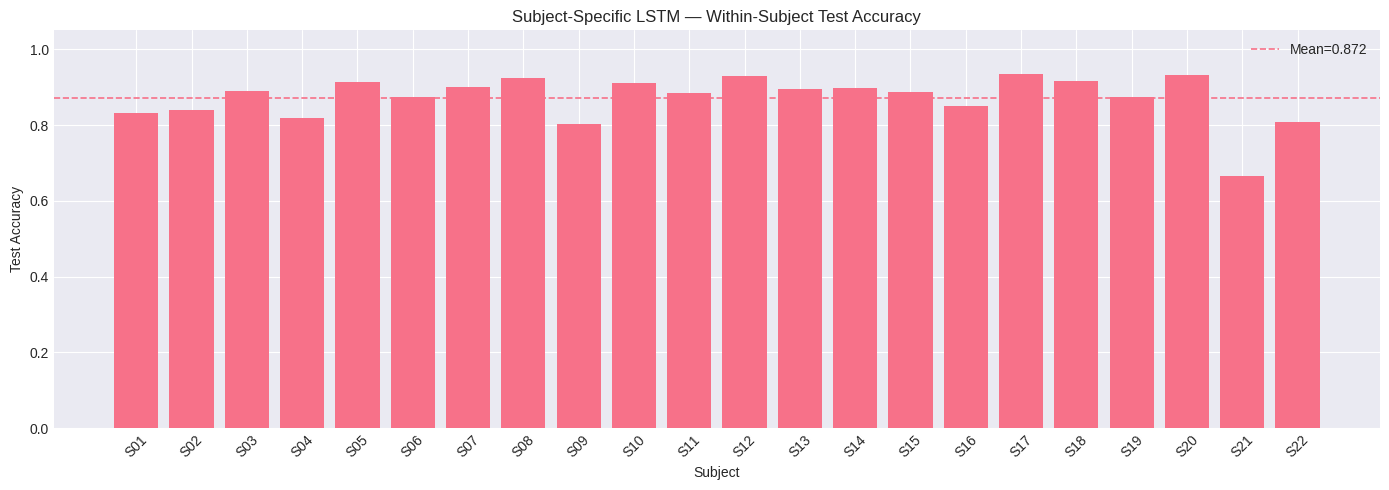

  Subject summary chart saved -> subject_specific_lstm_accuracy_summary.png

  FINAL SUBJECT-SPECIFIC WITHIN-SUBJECT LSTM SUMMARY
 subject  accuracy  balanced_accuracy     f1_w  roc_auc_w  best_epoch
       1  0.831933           0.828244 0.824138   0.981626          16
       2  0.839695           0.847633 0.837775   0.986497          23
       3  0.889474           0.906924 0.885224   0.996000          15
       4  0.818919           0.831811 0.811436   0.987705          20
       5  0.912959           0.913994 0.913830   0.995442          30
       6  0.873311           0.874982 0.861288   0.990543          35
       7  0.899314           0.908945 0.897882   0.993219          17
       8  0.924603           0.930481 0.924085   0.997888          21
       9  0.802632           0.813764 0.796013   0.991261          13
      10  0.911417           0.918898 0.908051   0.988831          18
      11  0.883632           0.883366 0.883059   0.995734          17
      12  0.929658           0

In [15]:
assert len(Config.SUBJECTS) == 22
assert set(Config.SUBJECTS) == set(
    range(1, 23)
)
assert set(
    Config.RUN_SUBJECTS
).issubset(
    set(Config.SUBJECTS)
)

assert Config.TRAIN_REPS == 4
assert Config.VAL_REPS == 1
assert Config.TEST_REPS == 1
assert (
    Config.TRAIN_REPS
    + Config.VAL_REPS
    + Config.TEST_REPS
    == Config.REPS_PER_GESTURE
)

assert Config.WIN_MS == 400
assert Config.STEP_MS == 100
assert Config.LSTM_FRAME_MS == 100
assert Config.LSTM_STEPS == 4
assert Config.USE_ACC is True

print(
    'Running TRUE subject-specific within-subject LSTM '
    'with strict leakage-safe EMG + ACC.'
)
print(
    f'Subject models: '
    f'{Config.RUN_SUBJECTS}'
)
print(
    'For every subject/gesture: '
    '4 complete train repetitions + '
    '1 validation + 1 test repetition.'
)
print(
    'Safe order: split repetition -> filter EMG locally -> '
    'slice/resample ACC locally -> 400 ms windows -> '
    '4-step temporal EMG sequence + separate ACC features -> '
    'training-only scaling.'
)
print(
    f'LSTM input: '
    f'{Config.LSTM_STEPS} temporal EMG steps '
    f'× {Config.LSTM_FRAME_MS} ms, plus a separate ACC branch.'
)

(
    all_metrics,
    per_subject_results,
    aggregate_results,
    all_y_true,
    all_y_proba,
    repetition_assignments,
    repetition_provenance,
) = main_subject_specific_lstm()

print('\nExperiment complete.')
print(
    'Interpretation: strict leakage-safe subject-specific '
    'EMG+ACC LSTM evaluated on unseen repetitions '
    'of the same participant.'
)

In [16]:
print('\n' + '=' * 70)
print(
    '  TRUE WITHIN-SUBJECT LSTM EMG+ACC RESULT '
    '— ONE MODEL PER SUBJECT'
)
print('=' * 70)

print(
    per_subject_results[
        [
            'subject',
            'accuracy',
            'balanced_accuracy',
            'precision_w',
            'recall_w',
            'f1_w',
            'roc_auc_w',
        ]
    ].to_string(index=False)
)

print(
    '\nAcross subject-specific '
    'LSTM models:'
)
print(
    f'Mean Accuracy          : '
    f'{aggregate_results["mean_subject_accuracy"]:.4f} '
    f'± '
    f'{aggregate_results["std_subject_accuracy"]:.4f}'
)
print(
    f'Mean Balanced Accuracy : '
    f'{aggregate_results["mean_subject_balanced_accuracy"]:.4f} '
    f'± '
    f'{aggregate_results["std_subject_balanced_accuracy"]:.4f}'
)
print(
    f'Mean F1 (weighted)     : '
    f'{aggregate_results["mean_subject_f1_w"]:.4f} '
    f'± '
    f'{aggregate_results["std_subject_f1_w"]:.4f}'
)
print(
    f'Pooled Test Accuracy   : '
    f'{aggregate_results["pooled_test_accuracy"]:.4f}'
)

print(
    '\nReport this as: strict leakage-safe subject-specific '
    'within-subject EMG+ACC LSTM evaluation. '
    'A separate LSTM is trained for each '
    'DB7 subject using 4 training, '
    '1 validation, and 1 held-out test '
    'repetition per gesture.'
)


  TRUE WITHIN-SUBJECT LSTM EMG+ACC RESULT — ONE MODEL PER SUBJECT
 subject  accuracy  balanced_accuracy  precision_w  recall_w     f1_w  roc_auc_w
       1  0.831933           0.828244     0.843824  0.831933 0.824138   0.981626
       2  0.839695           0.847633     0.853900  0.839695 0.837775   0.986497
       3  0.889474           0.906924     0.899879  0.889474 0.885224   0.996000
       4  0.818919           0.831811     0.835474  0.818919 0.811436   0.987705
       5  0.912959           0.913994     0.922428  0.912959 0.913830   0.995442
       6  0.873311           0.874982     0.881887  0.873311 0.861288   0.990543
       7  0.899314           0.908945     0.911729  0.899314 0.897882   0.993219
       8  0.924603           0.930481     0.930852  0.924603 0.924085   0.997888
       9  0.802632           0.813764     0.822192  0.802632 0.796013   0.991261
      10  0.911417           0.918898     0.920378  0.911417 0.908051   0.988831
      11  0.883632           0.883366     